In [ ]:
# ── Mount Drive ───────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Project root (everything lives here — survives disconnects) ───────────────
PROJECT_ROOT = "/content/drive/MyDrive/deforestation_detection"

import os
os.makedirs(PROJECT_ROOT, exist_ok=True)
print("✅ Drive mounted. Project root:", PROJECT_ROOT)

Mounted at /content/drive
✅ Drive mounted. Project root: /content/drive/MyDrive/deforestation_detection


In [ ]:
import os, shutil, random
from pathlib import Path

# ── Your dataset path ─────────────────────────────────────────────────────────
EUROSAT_DIR = Path("/content/drive/MyDrive/Eurosat")

# ── Output path (also in Drive — survives disconnects) ────────────────────────
ROOT    = Path("/content/drive/MyDrive/deforestation_detection")
OUT_DIR = ROOT / "data/eurosat_binary"

# ── Check what classes are available in your dataset ─────────────────────────
available_classes = [d.name for d in EUROSAT_DIR.iterdir() if d.is_dir()]
print("Classes found in your EuroSAT folder:")
for c in sorted(available_classes):
    count = len(list((EUROSAT_DIR / c).glob("*.jpg")))
    print(f"  {c:25s} → {count} images")

Classes found in your EuroSAT folder:
  AnnualCrop                → 3000 images
  Forest                    → 3000 images
  HerbaceousVegetation      → 3027 images
  Highway                   → 2500 images
  Industrial                → 2500 images
  Pasture                   → 2000 images
  PermanentCrop             → 2500 images
  Residential               → 3000 images
  River                     → 2500 images
  SeaLake                   → 3000 images


In [ ]:
import random
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image

EUROSAT_DIR    = Path("/content/drive/MyDrive/Eurosat")
FOREST_CLASSES = {"Forest"}
random.seed(42)

# ── Collect + balance in memory (no file copying) ─────────────────────────────
forest_imgs     = []
non_forest_imgs = []

for cls_dir in EUROSAT_DIR.iterdir():
    if not cls_dir.is_dir():
        continue
    imgs = list(cls_dir.glob("*.jpg"))
    if cls_dir.name in FOREST_CLASSES:
        forest_imgs.extend(imgs)
    else:
        non_forest_imgs.extend(imgs)

# Undersample non_forest to match forest count
non_forest_imgs = random.sample(non_forest_imgs, len(forest_imgs))

print(f"Forest     : {len(forest_imgs)}")
print(f"Non-Forest : {len(non_forest_imgs)}")
print(f"Total      : {len(forest_imgs) + len(non_forest_imgs)}")

# ── Build labeled list [(path, label), ...] ───────────────────────────────────
all_data = [(p, 1) for p in forest_imgs] + \
           [(p, 0) for p in non_forest_imgs]
random.shuffle(all_data)

# ── Split indices ──────────────────────────────────────────────────────────────
n       = len(all_data)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

train_data = all_data[:n_train]
val_data   = all_data[n_train : n_train + n_val]
test_data  = all_data[n_train + n_val :]

print(f"\nSplit — train: {len(train_data)} | val: {len(val_data)} | test: {len(test_data)}")

# ── Custom Dataset (reads directly from EuroSAT, no copying) ──────────────────
class ForestDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data      = data        # list of (Path, label)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        path, label = self.data[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

print("✅ Done — no files copied, reads straight from Drive.")

Forest     : 3000
Non-Forest : 3000
Total      : 6000

Split — train: 4200 | val: 900 | test: 900
✅ Done — no files copied, reads straight from Drive.


In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_ds = ForestDataset(train_data, transform=train_tf)
val_ds   = ForestDataset(val_data,   transform=val_tf)
test_ds  = ForestDataset(test_data,  transform=val_tf)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_dl   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)
test_dl  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 4200 | Val: 900 | Test: 900


In [ ]:
!pip install torch torchvision -q

import torch
import torch.nn as nn
from torchvision import models
import copy, time

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ⚠️ If it says 'cpu' go to:
# Runtime → Change runtime type → T4 GPU → Save → then re-run from Cell 0

Device: cuda


In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 1)   # binary output
model    = model.to(DEVICE)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("✅ Model ready.")
print(f"   Output layer : Linear(512 → 1) + Sigmoid")
print(f"   Loss         : BCEWithLogitsLoss")
print(f"   Optimizer    : Adam  lr=1e-4")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 129MB/s]


✅ Model ready.
   Output layer : Linear(512 → 1) + Sigmoid
   Loss         : BCEWithLogitsLoss
   Optimizer    : Adam  lr=1e-4


In [ ]:
from pathlib import Path

MODEL_SAVE = Path("/content/drive/MyDrive/deforestation_detection/models")
MODEL_SAVE.mkdir(parents=True, exist_ok=True)
MODEL_SAVE = MODEL_SAVE / "best_model.pth"

EPOCHS        = 15
best_val_loss = float("inf")
best_weights  = copy.deepcopy(model.state_dict())
history       = {"train_loss": [], "val_loss": []}

print(f"Training for {EPOCHS} epochs on {DEVICE}...\n")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>10} {'Time':>7}  ")
print("-" * 48)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # ── Train ──────────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for imgs, labels in train_dl:
        imgs   = imgs.to(DEVICE)
        labels = labels.float().unsqueeze(1).to(DEVICE)

        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(imgs)
    train_loss /= len(train_ds)

    # ── Validate ───────────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, labels in val_dl:
            imgs   = imgs.to(DEVICE)
            labels = labels.float().unsqueeze(1).to(DEVICE)
            val_loss += criterion(model(imgs), labels).item() * len(imgs)
    val_loss /= len(val_ds)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    elapsed = time.time() - t0
    saved   = ""

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights  = copy.deepcopy(model.state_dict())
        torch.save(best_weights, MODEL_SAVE)
        saved = "  ✓ saved"

    print(f"{epoch:>6}/{EPOCHS}  {train_loss:>12.4f}  {val_loss:>10.4f}  "
          f"{elapsed:>5.0f}s{saved}")

print(f"\n✅ Training complete.")
print(f"   Best val loss : {best_val_loss:.4f}")
print(f"   Model saved   : {MODEL_SAVE}")

Training for 15 epochs on cuda...

 Epoch   Train Loss   Val Loss    Time  
------------------------------------------------
     1/15        0.0756      0.0381    531s  ✓ saved
     2/15        0.0367      0.0182     32s  ✓ saved
     3/15        0.0188      0.0163     32s  ✓ saved
     4/15        0.0135      0.0165     32s
     5/15        0.0230      0.0097     30s  ✓ saved
     6/15        0.0121      0.0133     32s
     7/15        0.0269      0.0129     30s
     8/15        0.0080      0.0070     31s  ✓ saved
     9/15        0.0060      0.0093     33s
    10/15        0.0080      0.0063     32s  ✓ saved
    11/15        0.0137      0.0072     33s
    12/15        0.0126      0.0068     30s
    13/15        0.0119      0.0063     31s
    14/15        0.0128      0.0102     31s
    15/15        0.0079      0.0081     30s

✅ Training complete.
   Best val loss : 0.0063
   Model saved   : /content/drive/MyDrive/deforestation_detection/models/best_model.pth


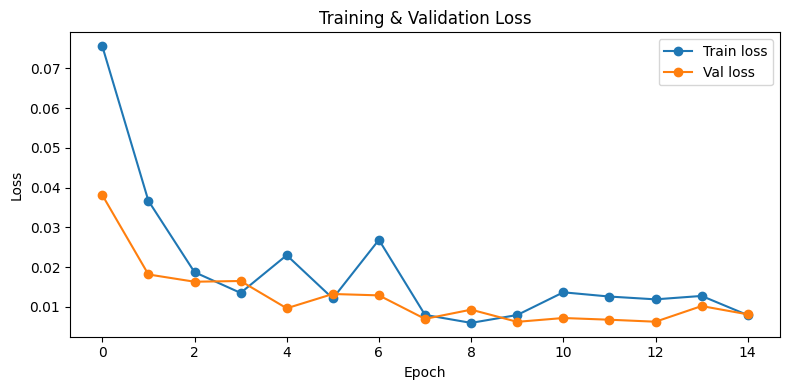

Saved: /content/drive/MyDrive/deforestation_detection/outputs/metrics/loss_curve.png


In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], marker="o", label="Train loss")
plt.plot(history["val_loss"],   marker="o", label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.tight_layout()

plot_path = Path("/content/drive/MyDrive/deforestation_detection/outputs/metrics/loss_curve.png")
plot_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved: {plot_path}")

In [ ]:
!pip install scikit-learn seaborn -q

import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

!pip install scikit-learn seaborn -q

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_SAVE = Path("/content/drive/MyDrive/deforestation_detection/models/best_model.pth")
OUT_DIR    = Path("/content/drive/MyDrive/deforestation_detection/outputs/metrics")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Load best model ────────────────────────────────────────────────────────────
model = models.resnet18()
model.fc = nn.Linear(model.fc.in_features, 1)
model.load_state_dict(torch.load(MODEL_SAVE, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

# ── Run inference on test set ──────────────────────────────────────────────────
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_dl, desc="Inference"):
        imgs   = imgs.to(DEVICE)
        logits = model(imgs).squeeze(1)
        probs  = torch.sigmoid(logits).cpu()
        preds  = (probs >= 0.5).long()

        all_probs.extend(probs.numpy())
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

print("✅ Inference complete on", len(all_labels), "test images.")

Inference: 100%|██████████| 29/29 [01:16<00:00,  2.65s/it]

✅ Inference complete on 900 test images.


In [ ]:
acc  = accuracy_score (all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec  = recall_score   (all_labels, all_preds)
f1   = f1_score       (all_labels, all_preds)

print("=" * 40)
print(f"  Accuracy   :  {acc:.4f}  ({acc*100:.1f}%)")
print(f"  Precision  :  {prec:.4f}")
print(f"  Recall     :  {rec:.4f}")
print(f"  F1-Score   :  {f1:.4f}  ← primary metric")
print("=" * 40)

print("\nFull classification report:")
print(classification_report(
    all_labels, all_preds,
    target_names=["Non-Forest", "Forest"]
))

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Non-Forest", "Forest"],
    yticklabels=["Non-Forest", "Forest"],
    linewidths=0.5
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()

cm_path = OUT_DIR / "confusion_matrix.png"
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"Saved: {cm_path}")

In [ ]:
import numpy as np

forest_probs     = [p for p, l in zip(all_probs, all_labels) if l == 1]
nonforest_probs  = [p for p, l in zip(all_probs, all_labels) if l == 0]

plt.figure(figsize=(8, 4))
plt.hist(forest_probs,    bins=30, alpha=0.7, color="green",  label="Forest")
plt.hist(nonforest_probs, bins=30, alpha=0.7, color="orange", label="Non-Forest")
plt.axvline(0.5, color="red", linestyle="--", linewidth=1.2, label="Decision boundary (0.5)")
plt.xlabel("Predicted probability of Forest")
plt.ylabel("Count")
plt.title("Confidence Distribution — Test Set")
plt.legend()
plt.tight_layout()

dist_path = OUT_DIR / "confidence_distribution.png"
plt.savefig(dist_path, dpi=150)
plt.show()
print(f"Saved: {dist_path}")

In [ ]:
!pip install grad-cam -q

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_SAVE = Path("/content/drive/MyDrive/deforestation_detection/models/best_model.pth")
OUT_DIR    = Path("/content/drive/MyDrive/deforestation_detection/outputs/gradcam")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Load model ─────────────────────────────────────────────────────────────────
model = models.resnet18()
model.fc = nn.Linear(model.fc.in_features, 1)
model.load_state_dict(torch.load(MODEL_SAVE, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

target_layer = [model.layer4[-1]]   # last conv block of ResNet18

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

print("✅ Grad-CAM ready.")

In [ ]:
def run_gradcam(img_path, true_label, title="", save_name=""):
    # ── Prepare image ──────────────────────────────────────────────────────────
    img        = Image.open(img_path).convert("RGB").resize((224, 224))
    img_np     = np.array(img) / 255.0
    tensor     = tf(img).unsqueeze(0).to(DEVICE)

    # ── Predict ────────────────────────────────────────────────────────────────
    with torch.no_grad():
        prob = torch.sigmoid(model(tensor).squeeze()).item()

    pred_label = "Forest" if prob >= 0.5 else "Non-Forest"
    true_name  = "Forest" if true_label == 1 else "Non-Forest"
    confidence = prob if prob >= 0.5 else 1 - prob
    correct    = "✓ Correct" if pred_label == true_name else "✗ Wrong"

    # ── Generate heatmap ───────────────────────────────────────────────────────
    with GradCAM(model=model, target_layers=target_layer) as cam:
        grayscale_cam = cam(input_tensor=tensor, targets=None)[0]

    overlay = show_cam_on_image(img_np.astype(np.float32),
                                grayscale_cam, use_rgb=True)

    # ── Plot ───────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(overlay)
    axes[1].set_title(f"Grad-CAM Heatmap")
    axes[1].axis("off")

    axes[2].imshow(grayscale_cam, cmap="jet")
    axes[2].set_title("Raw activation map")
    axes[2].axis("off")

    fig.suptitle(
        f"{title}\n"
        f"True: {true_name}  |  Pred: {pred_label}  |  "
        f"Confidence: {confidence*100:.1f}%  |  {correct}",
        fontsize=11
    )
    plt.tight_layout()

    out_path = OUT_DIR / f"{save_name}.png"
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved: {out_path}")

In [ ]:
# Pick a random forest image from test set
forest_samples = [(path, label) for path, label in test_data if label == 1]
img_path, true_label = random.choice(forest_samples)

run_gradcam(
    img_path    = img_path,
    true_label  = true_label,
    title       = "Correctly classified — Forest",
    save_name   = "gradcam_correct_forest"
)

In [ ]:
# ── Find a misclassified image from test set ───────────────────────────────────
print("Searching for misclassified image...")

misclassified = []
with torch.no_grad():
    for path, label in test_data:
        img    = Image.open(path).convert("RGB").resize((224, 224))
        tensor = tf(img).unsqueeze(0).to(DEVICE)
        prob   = torch.sigmoid(model(tensor).squeeze()).item()
        pred   = 1 if prob >= 0.5 else 0
        if pred != label:
            misclassified.append((path, label))
        if len(misclassified) >= 10:   # stop early once we have enough
            break

if misclassified:
    img_path, true_label = random.choice(misclassified)
    run_gradcam(
        img_path   = img_path,
        true_label = true_label,
        title      = "Misclassified example",
        save_name  = "gradcam_misclassified"
    )
else:
    print("🎉 No misclassified images found — model is performing very well!")

In [ ]:
non_forest_samples = [(path, label) for path, label in test_data if label == 0]
img_path, true_label = random.choice(non_forest_samples)

run_gradcam(
    img_path   = img_path,
    true_label = true_label,
    title      = "Non-Forest sample",
    save_name  = "gradcam_non_forest"
)

In [ ]:
!pip install streamlit pyngrok grad-cam -q

In [ ]:
from pathlib import Path

app_code = '''
import streamlit as st
import torch
import torch.nn as nn
from torchvision import transforms, models
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from PIL import Image
import numpy as np

# ── Config ─────────────────────────────────────────────────────────────────────
MODEL_PATH = "/content/drive/MyDrive/deforestation_detection/models/best_model.pth"
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mean       = [0.485, 0.456, 0.406]
std        = [0.229, 0.224, 0.225]

# ── Load model (cached so it loads only once) ──────────────────────────────────
@st.cache_resource
def load_model():
    m = models.resnet18()
    m.fc = nn.Linear(m.fc.in_features, 1)
    m.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    return m.to(DEVICE).eval()

model        = load_model()
target_layer = [model.layer4[-1]]

tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# ── UI ─────────────────────────────────────────────────────────────────────────
st.set_page_config(page_title="Deforestation Detector", page_icon="🌿")

st.title("🌿 Satellite Deforestation Detector")
st.caption("Binary classifier · Forest vs Non-Forest · SDG 15 – Life on Land")
st.markdown("---")

uploaded = st.file_uploader(
    "Upload a satellite image patch (JPG / PNG)",
    type=["jpg", "jpeg", "png"]
)

if uploaded is not None:
    # ── Preprocess ─────────────────────────────────────────────────────────────
    img         = Image.open(uploaded).convert("RGB")
    img_resized = img.resize((224, 224))
    img_np      = np.array(img_resized) / 255.0
    tensor      = tf(img_resized).unsqueeze(0).to(DEVICE)

    # ── Predict ────────────────────────────────────────────────────────────────
    with torch.no_grad():
        prob = torch.sigmoid(model(tensor).squeeze()).item()

    is_forest  = prob >= 0.5
    label      = "🌲 Forest" if is_forest else "🏗️ Non-Forest"
    confidence = prob if is_forest else 1 - prob
    bar_color  = "green" if is_forest else "orange"

    # ── Grad-CAM ───────────────────────────────────────────────────────────────
    with GradCAM(model=model, target_layers=target_layer) as cam:
        grayscale_cam = cam(input_tensor=tensor, targets=None)[0]
    overlay = show_cam_on_image(img_np.astype(np.float32),
                                grayscale_cam, use_rgb=True)

    # ── Display ────────────────────────────────────────────────────────────────
    col1, col2 = st.columns(2)
    col1.image(img_resized, caption="Uploaded image",   use_column_width=True)
    col2.image(overlay,     caption="Grad-CAM heatmap", use_column_width=True)

    st.markdown("---")

    # Result box
    st.markdown(f"### Prediction: **{label}**")

    st.metric(
        label  = "Confidence",
        value  = f"{confidence * 100:.1f}%"
    )
    st.progress(int(confidence * 100))

    # SDG note
    st.markdown("---")
    st.info(
        "🌍 **SDG 15 – Life on Land** · "
        "This tool helps automate forest cover monitoring "
        "from Sentinel-2 satellite imagery."
    )

else:
    # Placeholder when nothing uploaded
    st.info("👆 Upload a satellite image patch above to get started.")
    st.markdown("""
    **What this model does:**
    - Takes a 64×64 satellite image patch
    - Classifies it as Forest or Non-Forest
    - Shows a Grad-CAM heatmap of where the model looked

    **Model:** ResNet18 pretrained on ImageNet, fine-tuned on EuroSAT
    """)
'''

app_path = Path("/content/drive/MyDrive/deforestation_detection/app.py")
app_path.write_text(app_code)
print("✅ app.py written to Drive:", app_path)

In [ ]:
import subprocess, time
from pyngrok import ngrok

# ── Your free token from https://dashboard.ngrok.com/get-started/your-authtoken
NGROK_TOKEN = "XXXX"
ngrok.set_auth_token(NGROK_TOKEN)

# Kill any existing Streamlit processes
!pkill -f streamlit 2>/dev/null
time.sleep(2)

# Launch Streamlit in background
subprocess.Popen(
    ["streamlit", "run", str(app_path),
     "--server.port", "8501",
     "--server.headless", "true",
     "--server.enableCORS", "false"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)
time.sleep(5)

# Open tunnel
tunnel = ngrok.connect(8501)
print("=" * 50)
print("✅ App is live!")
print("🔗 Open this link:", tunnel.public_url)
print("=" * 50)
print("To stop the app run:  ngrok.disconnect(tunnel.public_url)")